##Implement an End to End CNN Model for Image Classification Task.

##Task 1: Data Understanding and Visualization:

Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

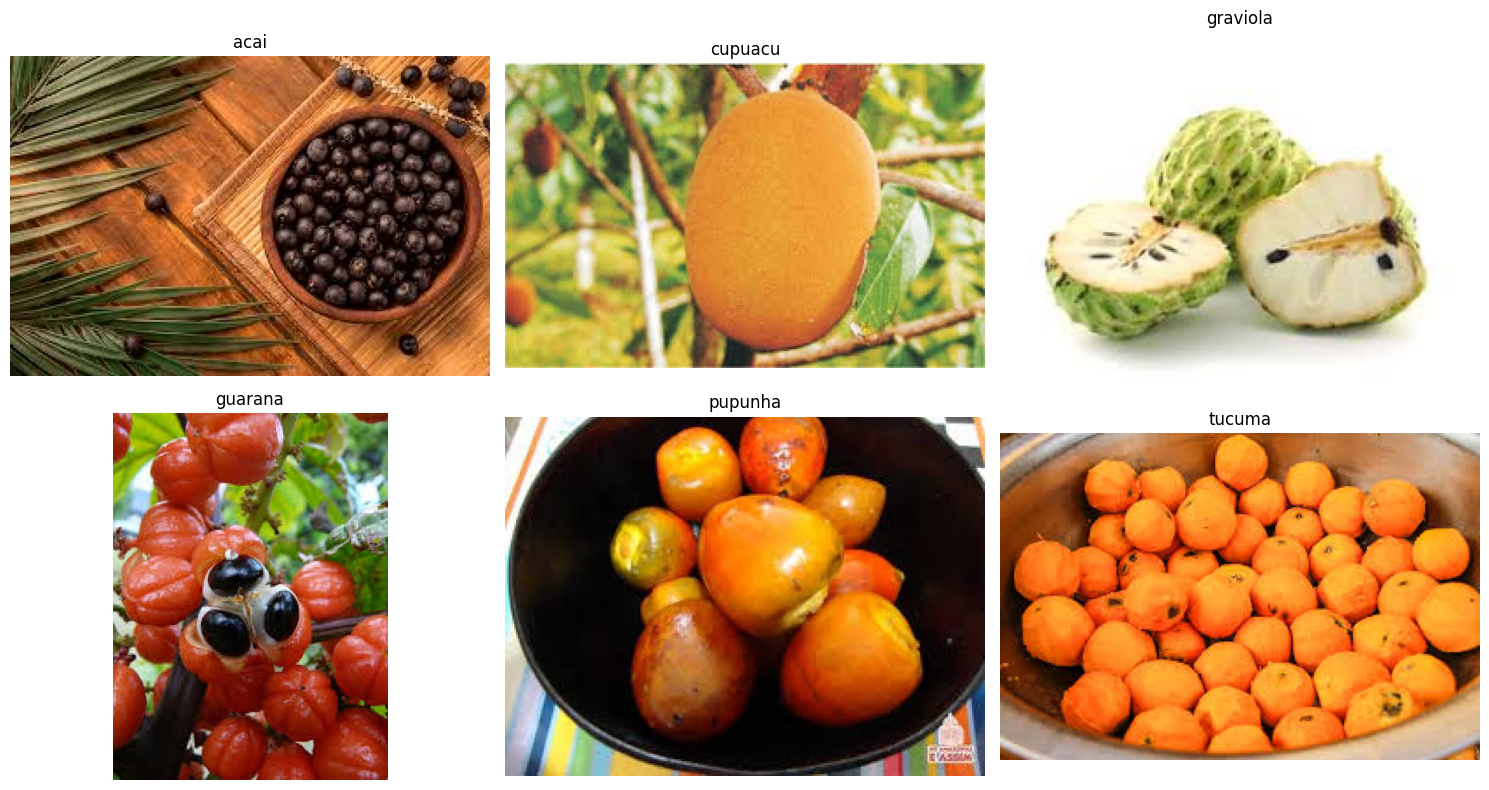

In [21]:
import os
import random
import math
from PIL import Image
import matplotlib.pyplot as plt

# Path to train folder
train_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"

# Get all class folders inside train
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
class_dirs.sort()

# Pick one random image from each class
selected_images = []

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]

    if len(image_files) > 0:
        random_image = random.choice(image_files)
        selected_images.append((class_name, os.path.join(class_path, random_image)))

# Display images in grid with 2 rows
num_classes = len(selected_images)
rows = 2
cols = math.ceil(num_classes / rows)

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(selected_images):
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Observation:
The dataset is organized into separate folders, with each folder representing a different fruit class. The sample images show noticeable differences in color, shape, and texture across classes, although a few fruits appear visually similar. Variations in background, lighting, and image angle are also present, which may increase the difficulty of the classification task.

Check for Corrupted Image:

In [22]:
import os
from PIL import Image

# Path to train folder
train_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"

corrupted_images = []

# Loop through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            image_path = os.path.join(class_path, file_name)

            # Check only image files
            if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                try:
                    with Image.open(image_path) as img:
                        img.verify()   # checks if image is valid

                except (IOError, OSError, SyntaxError):
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")

# Final result
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [23]:
import tensorflow as tf

# Paths
train_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

# Parameters
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

# Save class names before normalization
class_names = train_ds.class_names

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Show class names
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


##Task 3 - Implement a CNN

In [24]:
from tensorflow.keras import layers, models

# Number of classes
num_classes = len(class_names)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

# Show model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

##Task 4: Compile the Model

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##Task 4: Train the Model

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.1181 - loss: 1.9534
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step - accuracy: 0.1528 - loss: 1.9697 - val_accuracy: 0.0000e+00 - val_loss: 2.2160
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.2295 - loss: 1.8247
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 0.2361 - loss: 1.7895 - val_accuracy: 0.0000e+00 - val_loss: 1.8629
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.1674 - loss: 1.7041
Epoch 3: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.2222 - loss: 1.6682 - val_accuracy: 0.0000e+00 - val_loss: 1.8562
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.3090 - loss: 1.5564
Epoch 4: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.3472 - loss: 1.5350 - val_accuracy: 0.0000e+00 - val_loss: 1.8612
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.61


Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 736ms/step - accuracy: 0.5694 - loss: 1.2237 - val_accuracy: 0.1667 - val_loss: 1.5709
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6740 - loss: 0.9949
Epoch 6: val_accuracy improved from 0.16667 to 0.55556, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.7083 - loss: 0.9408 - val_accuracy: 0.5556 - val_loss: 1.2527
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7486 - loss: 0.6554
Epoch 7: val_accuracy improved from 0.55556 to 0.83333, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.6806 - loss: 0.7476 - val_accuracy: 0.8333 - val_loss: 0.7469
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9087 - loss: 0.4687
Epoch 8: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 0.9028 - loss: 0.4458 - val_accuracy: 0.8889 - val_loss: 0.7347
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9899 - loss: 0.2933
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.9861 - loss: 0.2806 - val_accuracy: 0.8333 - val_loss: 0.5522
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9837 - loss: 0.1811
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 0.9861 - loss: 0.1659 - val_accuracy: 0.8333 - val_loss: 0.4720
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9712 - loss: 0.0902
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 514ms/step - accuracy: 0.9861 - loss: 0.0630 - val_accuracy: 0.8333 - val_loss: 0.3876
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 

# Accuracy Graph

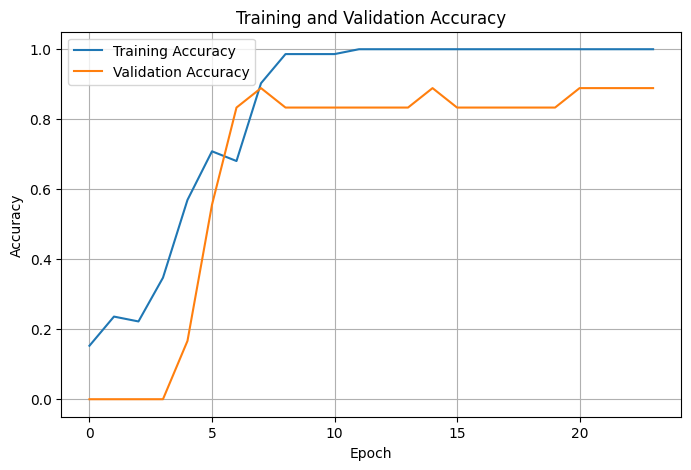

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Loss Graph

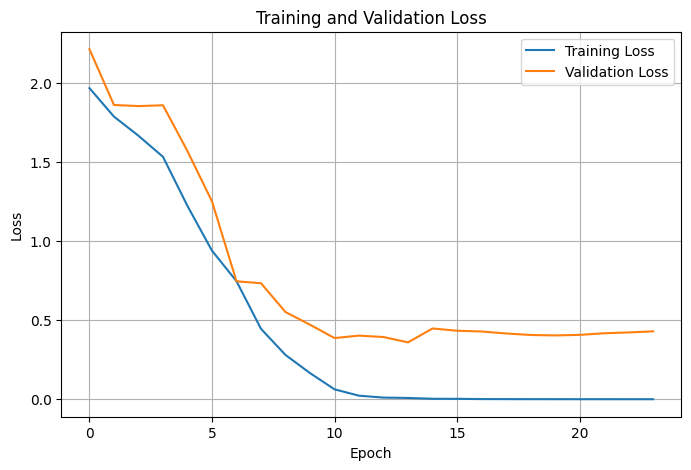

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

##Task 5: Evaluate the Model

In [29]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7333 - loss: 0.8275
Test Loss: 0.827468991279602
Test Accuracy: 0.7333333492279053


##Task 6: Save and Load the Model

In [30]:
model.save("/content/drive/MyDrive/AI and ML/FruitinAmazon/fruit_cnn_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [31]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/AI and ML/FruitinAmazon/fruit_cnn_model.h5")

In [32]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7333 - loss: 0.8275
Loaded Model Test Loss: 0.827468991279602
Loaded Model Test Accuracy: 0.7333333492279053


##Task 7: Predictions and Classification Report

In [33]:
import numpy as np
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      0.80      0.62         5
    graviola       0.83      1.00      0.91         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.72        30
weighted avg       0.80      0.73      0.72        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


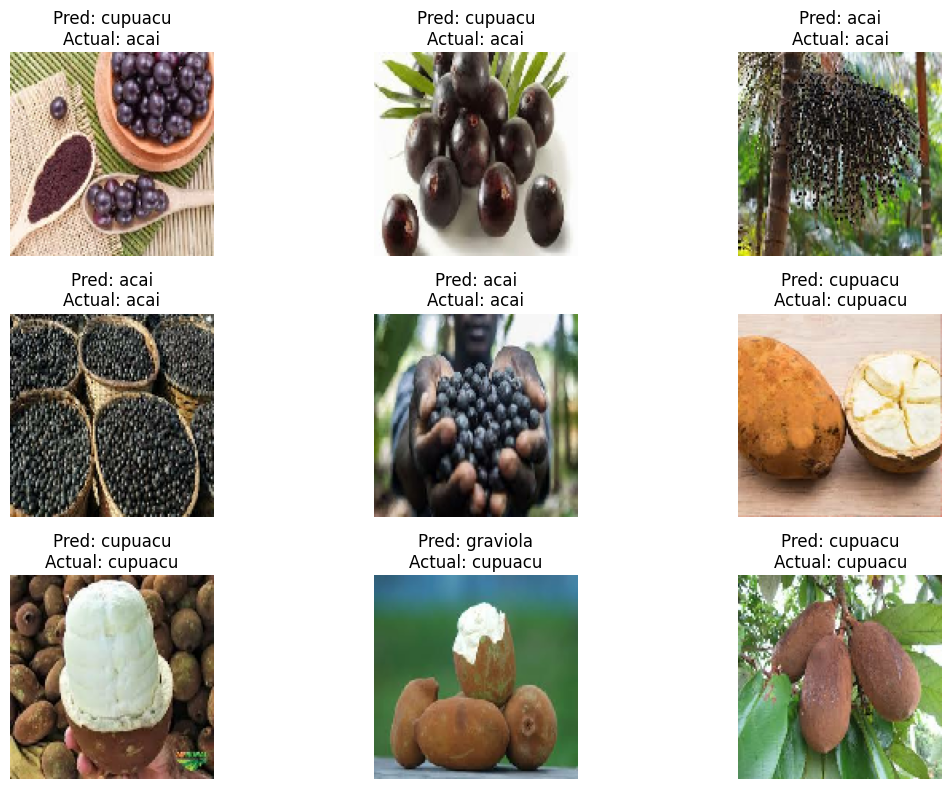

In [35]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[predicted_labels[i]]}\nActual: {class_names[labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()